# Quantum Gates, A Hands-On
### Quantum Computing Education Series by Trinexis

**Where we are in the course.** We have covered qubits, state vectors, the Bloch
sphere, density matrices, and measures of quantum information (purity, coherence,
entanglement, noise). We now build the *verbs* of quantum computing: **quantum gates**.

**The one-line thesis of this notebook**

> *A quantum gate is a **unitary** operator, a reversible, norm-preserving rotation of
> the quantum state. Single-qubit gates rotate the Bloch sphere; two-qubit gates like
> CNOT create entanglement; a tiny universal set runs any computation.*

We keep the **Stern–Gerlach (SG) cascade** as our physical anchor throughout, exactly
as in Notebooks 1–4.

---
**How to use this notebook:** Run the cells top to bottom (`Runtime → Run all` in Colab).
Every section has a short explanation, runnable code, and a takeaway. Graded exercises
(★ easy → ★★★ hard) with collapsible solutions are at the end. After a first pass,
**change the numbers and re-run**, that is how the intuition will be built.

## Learning objectives

By the end, one will be able to:

1. State the defining property of a quantum gate (**unitarity**) and *check it in code*.
2. Derive and verify the core characteristics: **norm preservation, reversibility,
   inner-product preservation, linearity**.
3. Build and apply the standard single-qubit gates (**X, Y, Z, H, S, T, Rx, Ry, Rz**)
   and *see* their action as Bloch-sphere rotations.
4. Realize a gate as **time evolution** $U=e^{-iHt}$ (via eigendecomposition, no SciPy).
5. Compose gates (**series = product, parallel = tensor**) and quantify
   **non-commutativity**, the SG order-dependence.
6. Build **two-qubit gates** (CNOT, CZ, SWAP) and create a **Bell state** (entanglement).
7. Compare quantum vs classical gates: **reversibility, Toffoli bridge, no-cloning**.
8. Explore everything interactively and complete the exercises.

## 0. Setup

Same minimal stack as the rest of the course: **NumPy + Matplotlib (+ optional
ipywidgets)**. No SciPy, no Qiskit here, matrix exponentials are done by
eigendecomposition so the Hamiltonian → gate relationship stays explicit.
We fix the seed for reproducible in-class demonstrations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

np.random.seed(42)          # reproducible demos
np.set_printoptions(precision=4, suppress=True)

# ipywidgets is optional. In headless execution (grading/nbconvert) interact() can
# hang, so we guard every interactive cell. In live Colab the widgets appear normally.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

print("Setup complete.  NumPy", np.__version__, "| widgets:", HAVE_WIDGETS)

Setup complete.  NumPy 2.0.2 | widgets: True


## 1. The reusable toolkit

These are the same helper functions carried forward from Notebooks 1–4, plus a few
gate-specific additions. Reusing them keeps our notation consistent across the whole
course. Read the docstrings, they *are* the definitions.

In [2]:
# ----- states ---------------------------------------------------------------
KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)

def qubit_state(theta, phi):
    """Pure single-qubit state on the Bloch sphere:
       |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>."""
    return np.array([np.cos(theta/2),
                     np.exp(1j*phi)*np.sin(theta/2)], dtype=complex)

def normalize(psi):
    return psi / np.linalg.norm(psi)

# ----- Bloch geometry -------------------------------------------------------
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)

def bloch_vector(psi):
    """Bloch vector (x,y,z) = (<X>,<Y>,<Z>) of a pure state."""
    psi = normalize(psi)
    return np.array([np.vdot(psi, P @ psi).real for P in (X, Y, Z)])

def density_matrix_from_pure(psi):
    """rho = |psi><psi|."""
    psi = normalize(psi)
    return np.outer(psi, psi.conj())

def bloch_from_rho(rho):
    return np.array([np.trace(rho @ P).real for P in (X, Y, Z)])

def purity(rho):
    return np.trace(rho @ rho).real

# ----- measurement (the SG anchor) -----------------------------------------
def born_probs(psi):
    """Born-rule probabilities in the computational (z) basis."""
    psi = normalize(psi)
    return np.abs(psi)**2

def expectation(psi, A):
    """<psi| A |psi>."""
    psi = normalize(psi)
    return np.vdot(psi, A @ psi)

# ----- gate utilities (new this notebook) ----------------------------------
def is_unitary(U, tol=1e-10):
    """True iff U^dagger U = I  (the DEFINING property of a quantum gate)."""
    U = np.asarray(U, dtype=complex)
    n = U.shape[0]
    return np.allclose(U.conj().T @ U, np.eye(n), atol=tol)

def is_hermitian(A, tol=1e-10):
    A = np.asarray(A, dtype=complex)
    return np.allclose(A, A.conj().T, atol=tol)

def dagger(U):
    """Conjugate transpose = the inverse of any gate."""
    return np.asarray(U, dtype=complex).conj().T

def expm_herm(H, t=1.0):
    """U = exp(-i H t) for Hermitian H, via eigendecomposition (no SciPy).
       This is the 'gate = timed Hamiltonian evolution' relationship, explicit."""
    H = np.asarray(H, dtype=complex)
    evals, evecs = np.linalg.eigh(H)           # H = V diag(lambda) V^dagger
    return evecs @ np.diag(np.exp(-1j*evals*t)) @ evecs.conj().T

print("Toolkit loaded:", [f for f in dir() if f[0].islower() and f not in ('np','plt')][:12], "...")

Toolkit loaded: ['bloch_from_rho', 'bloch_vector', 'born_probs', 'dagger', 'density_matrix_from_pure', 'exit', 'expectation', 'expm_herm', 'get_ipython', 'interact', 'is_hermitian', 'is_unitary'] ...


## 2. What *makes* a quantum gate: unitarity

**Definition.** A quantum gate on $n$ qubits is a $2^n\times 2^n$ **unitary** matrix:
$$U^\dagger U = U U^\dagger = I.$$

That one equation implies everything else. Let's verify the consequences numerically
rather than take them on faith.

In [3]:
# The Hadamard gate, our running example
H = (1/np.sqrt(2)) * np.array([[1, 1],
                               [1, -1]], dtype=complex)

print("H =\n", H)
print("\nUnitary?  U^dag U = I :", is_unitary(H))
print("H^dag H =\n", (dagger(H) @ H).real)

H =
 [[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

Unitary?  U^dag U = I : True
H^dag H =
 [[ 1. -0.]
 [-0.  1.]]


### 2a. Consequence, probability (norm) is preserved

If total probability started at 1, it stays 1. This is *why* a gate is allowed to exist:
it never leaks or invents probability.

In [4]:
psi = qubit_state(theta=1.1, phi=0.7)      # some random-ish input state
print("input norm  :", np.linalg.norm(psi))
out = H @ psi
print("output norm :", np.linalg.norm(out))
print("input  Born probs :", np.round(born_probs(psi), 4), " sum =", born_probs(psi).sum())
print("output Born probs :", np.round(born_probs(out), 4), " sum =", born_probs(out).sum())

input norm  : 1.0
output norm : 0.9999999999999999
input  Born probs : [0.7268 0.2732]  sum = 1.0
output Born probs : [0.8408 0.1592]  sum = 1.0000000000000002


### 2b. Consequence, reversibility: the inverse of a gate is its adjoint

$$U^{-1} = U^\dagger.$$
There is **no** irreversible quantum gate. Whatever a gate did, $U^\dagger$ undoes exactly.
Contrast the classical AND gate, which throws away information and cannot be run backward.

In [5]:
restored = dagger(H) @ (H @ psi)          # apply H, then undo with H^dagger
print("original :", np.round(psi, 4))
print("restored :", np.round(restored, 4))
print("perfectly recovered? ", np.allclose(psi, restored))

original : [0.8525+0.j     0.3998+0.3367j]
restored : [0.8525+0.j     0.3998+0.3367j]
perfectly recovered?  True


### 2c. Consequence, inner products (angles / distinguishability) are preserved

$$\langle U\phi | U\psi\rangle = \langle\phi|\psi\rangle.$$
Orthogonal inputs stay orthogonal; a gate rotates the state space rigidly, without
distortion. **This single fact is the root of the no-cloning theorem** (Section 9).

In [6]:
phi = qubit_state(0.4, 2.0)
psi = qubit_state(2.3, -1.1)
before = np.vdot(phi, psi)
after  = np.vdot(H @ phi, H @ psi)
print("<phi|psi>       :", np.round(before, 6))
print("<Hphi|Hpsi>     :", np.round(after, 6))
print("preserved?      :", np.isclose(before, after))

<phi|psi>       : (0.219164-0.00754j)
<Hphi|Hpsi>     : (0.219164-0.00754j)
preserved?      : True


## 3. The single-qubit gate zoo

The standard building blocks. Note two families:
- **Pauli gates X, Y, Z** are *both* Hermitian and unitary → each is its own inverse.
- **H, S, T** are unitary but not Hermitian.

In [7]:
# Define the standard gates
S = np.array([[1, 0], [0, 1j]], dtype=complex)                 # phase (sqrt Z)
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex) # pi/8  (sqrt S)

GATES = {"I": I2, "X": X, "Y": Y, "Z": Z, "H": H, "S": S, "T": T}

print(f"{'gate':<5}{'unitary':<9}{'hermitian':<11}{'self-inverse (U^2=I)'}")
for name, G in GATES.items():
    print(f"{name:<5}{str(is_unitary(G)):<9}{str(is_hermitian(G)):<11}"
          f"{np.allclose(G @ G, I2)}")

gate unitary  hermitian  self-inverse (U^2=I)
I    True     True       True
X    True     True       True
Y    True     True       True
Z    True     True       True
H    True     True       True
S    True     False      False
T    True     False      False


### 3a. Action on the basis states

The most concrete way to *read* a gate. Because gates are **linear**, knowing the action
on $|0\rangle$ and $|1\rangle$ tells you the action on every superposition.

In [8]:
def show_action(name, G):
    out0, out1 = G @ KET0, G @ KET1
    def fmt(v):
        return f"[{v[0]:+.3f}, {v[1]:+.3f}]"
    print(f"{name}: |0> -> {fmt(out0)}   |1> -> {fmt(out1)}")

for name, G in GATES.items():
    show_action(name, G)

print("\nReadout:")
print("  X flips |0><->|1|  (quantum NOT).")
print("  Z leaves probabilities alone but flips the phase of |1>  (the SG 'which-path' phase).")
print("  H makes equal superpositions  |0>->|+>, |1>->|-|  (the SG z<->x basis change).")

I: |0> -> [+1.000+0.000j, +0.000+0.000j]   |1> -> [+0.000+0.000j, +1.000+0.000j]
X: |0> -> [+0.000+0.000j, +1.000+0.000j]   |1> -> [+1.000+0.000j, +0.000+0.000j]
Y: |0> -> [+0.000+0.000j, +0.000+1.000j]   |1> -> [+0.000-1.000j, +0.000+0.000j]
Z: |0> -> [+1.000+0.000j, +0.000+0.000j]   |1> -> [+0.000+0.000j, -1.000+0.000j]
H: |0> -> [+0.707+0.000j, +0.707+0.000j]   |1> -> [+0.707+0.000j, -0.707+0.000j]
S: |0> -> [+1.000+0.000j, +0.000+0.000j]   |1> -> [+0.000+0.000j, +0.000+1.000j]
T: |0> -> [+1.000+0.000j, +0.000+0.000j]   |1> -> [+0.000+0.000j, +0.707+0.707j]

Readout:
  X flips |0><->|1|  (quantum NOT).
  Z leaves probabilities alone but flips the phase of |1>  (the SG 'which-path' phase).
  H makes equal superpositions  |0>->|+>, |1>->|-|  (the SG z<->x basis change).


### 3b. SG anchor, Hadamard *is* the z↔x basis change

In the SG cascade, a $|{+}z\rangle$ spin entering an $x$-analyzer is 50/50. The Hadamard
is exactly the operator that rotates the $z$-basis into the $x$-basis. Apply $H$ to
$|0\rangle=|{+}z\rangle$ and measure in $z$: you get the 50/50 that the SG-$x$ apparatus
would have produced. And $H^2=I$, going $z\to x\to z$ returns you home.

In [9]:
plus = H @ KET0
print("H|0> = |+> =", np.round(plus, 4))
print("Born probs in z-basis:", np.round(born_probs(plus), 4), " <- the SG 50/50")
print("H applied twice returns |0>? ", np.allclose(H @ (H @ KET0), KET0))

H|0> = |+> = [0.7071+0.j 0.7071+0.j]
Born probs in z-basis: [0.5 0.5]  <- the SG 50/50
H applied twice returns |0>?  True


## 4. Seeing gates as Bloch-sphere rotations

Every single-qubit gate is a **rotation of the Bloch sphere**. Let's draw the input
arrow and the output arrow for a few gates.

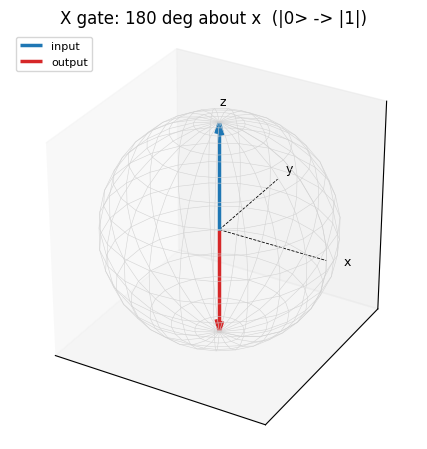

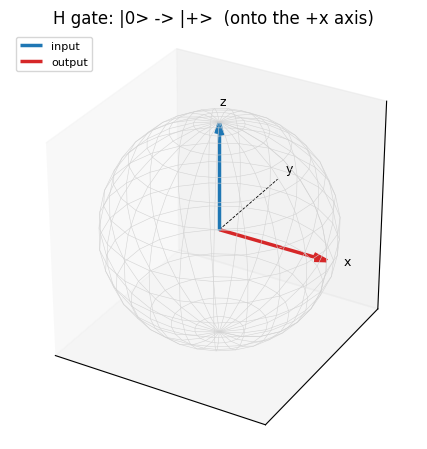

In [10]:
def draw_bloch(ax, vec, color, label):
    ax.quiver(0, 0, 0, *vec, color=color, arrow_length_ratio=0.12, linewidth=2.5, label=label)

def plot_gate_action(psi_in, gate, title):
    v_in  = bloch_vector(psi_in)
    v_out = bloch_vector(gate @ psi_in)
    fig = plt.figure(figsize=(4.6, 4.6))
    ax = fig.add_subplot(111, projection='3d')
    # wireframe sphere
    u = np.linspace(0, 2*np.pi, 24); v = np.linspace(0, np.pi, 16)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color='lightgray', linewidth=0.4)
    for a, lab in [((1,0,0),'x'),((0,1,0),'y'),((0,0,1),'z')]:
        ax.plot([0,a[0]],[0,a[1]],[0,a[2]],'k--',linewidth=0.6)
        ax.text(a[0]*1.15,a[1]*1.15,a[2]*1.15,lab,fontsize=9)
    draw_bloch(ax, v_in,  'tab:blue',   'input')
    draw_bloch(ax, v_out, 'tab:red',    'output')
    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
    ax.set_box_aspect((1,1,1)); ax.set_title(title); ax.legend(loc='upper left', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.tight_layout(); plt.show()

psi0 = KET0                      # start at the north pole |0>
plot_gate_action(psi0, X, "X gate: 180 deg about x  (|0> -> |1|)")
plot_gate_action(psi0, H, "H gate: |0> -> |+>  (onto the +x axis)")

**Read the pictures.** $X$ takes the north pole $|0\rangle$ to the south pole $|1\rangle$
- a 180° flip about the $x$-axis. $H$ takes $|0\rangle$ to the $+x$ equator point $|{+}\rangle$
- exactly the state whose $z$-measurement is 50/50 (the SG-$x$ result).

## 5. Rotation gates, the continuous knobs

Physical control produces *continuous* rotations. For a unit axis $\hat n$ and angle $\theta$:
$$R_{\hat n}(\theta)=e^{-i\theta(\hat n\cdot\vec\sigma)/2}
   =\cos\tfrac{\theta}{2}\,I-i\sin\tfrac{\theta}{2}\,(\hat n\cdot\vec\sigma).$$
We implement $R_x,R_y,R_z$ **two independent ways**, the closed form *and* the
Hamiltonian exponential `expm_herm`, and check they agree. That cross-check is the
whole point: a gate really is timed Hamiltonian evolution.

In [11]:
def Rx(theta):
    return np.array([[np.cos(theta/2),      -1j*np.sin(theta/2)],
                     [-1j*np.sin(theta/2),   np.cos(theta/2)]], dtype=complex)
def Ry(theta):
    return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                     [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)
def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0, np.exp(1j*theta/2)]], dtype=complex)

theta = 0.9
# closed form vs Hamiltonian exponential  R_n(theta) = exp(-i (theta/2) (n.sigma))
print("Rx closed form == exp(-i theta/2 X)? ",
      np.allclose(Rx(theta), expm_herm(X, theta/2)))
print("Ry closed form == exp(-i theta/2 Y)? ",
      np.allclose(Ry(theta), expm_herm(Y, theta/2)))
print("Rz closed form == exp(-i theta/2 Z)? ",
      np.allclose(Rz(theta), expm_herm(Z, theta/2)))
print("\nAll rotation gates unitary? ",
      all(is_unitary(R(theta)) for R in (Rx, Ry, Rz)))

Rx closed form == exp(-i theta/2 X)?  True
Ry closed form == exp(-i theta/2 Y)?  True
Rz closed form == exp(-i theta/2 Z)?  True

All rotation gates unitary?  True


### 5a. A rotation traces a smooth path on the sphere

Sweep $R_y(\theta)$ from $\theta=0$ to $\pi$ starting at $|0\rangle$: the Bloch vector
walks continuously from the north pole down to the south pole. This continuum of gates
has **no classical analogue** (classical single-bit logic has only 4 functions).

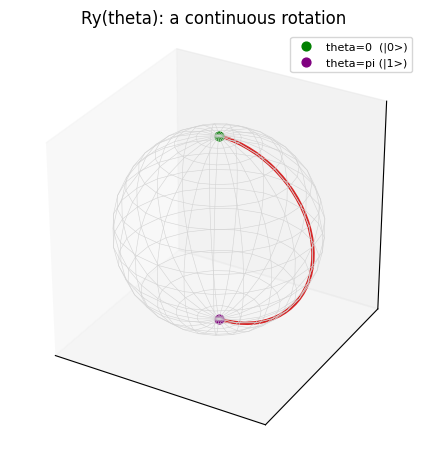

In [30]:
thetas = np.linspace(0, np.pi, 40)
path = np.array([bloch_vector(Ry(t) @ KET0) for t in thetas])

fig = plt.figure(figsize=(4.6, 4.6))
ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, 2*np.pi, 24); v = np.linspace(0, np.pi, 16)
ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                  np.outer(np.ones_like(u), np.cos(v)), color='lightgray', linewidth=0.4)
ax.plot(path[:,0], path[:,1], path[:,2], 'tab:red', linewidth=2.5)
ax.scatter(*path[0],  color='green', s=40, label='theta=0  (|0>)')
ax.scatter(*path[-1], color='purple', s=40, label='theta=pi (|1>)')
ax.set_box_aspect((1,1,1)); ax.set_title("Ry(theta): a continuous rotation")
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Gates as timed Hamiltonian evolution

Physically a gate is *"switch on Hamiltonian $H$ for time $t$"*:
$$U(t)=e^{-iHt/\hbar}\quad(\hbar=1\text{ in our units}).$$
Here is a concrete example: driving with $H=\tfrac{\Omega}{2}X$ (a resonant field) for a
time such that $\Omega t=\pi$ produces exactly the $X$ (NOT) gate, a "$\pi$-pulse".

In [31]:
Omega = 1.0
# pi-pulse: evolve under H = (Omega/2) X for time t = pi/Omega
H_drive = (Omega/2) * X
t_pi = np.pi / Omega
U_pulse = expm_herm(H_drive, t_pi)

print("U from a pi-pulse under H=(Omega/2)X:\n", np.round(U_pulse, 4))
print("\nEqual to the X gate (up to a global phase)?")
# strip global phase by comparing |U| structure and action on states
print("  U|0> =", np.round(U_pulse @ KET0, 4), "  (X|0> = |1>)")
print("  U|1> =", np.round(U_pulse @ KET1, 4), "  (X|1> = |0>)")
# a half pulse (Omega t = pi/2) is the sqrt(NOT) gate:
U_half = expm_herm(H_drive, t_pi/2)
print("\nHalf pulse = sqrt(NOT):  applying it twice gives NOT?",
      np.allclose((U_half @ U_half) @ KET0, U_pulse @ KET0))

U from a pi-pulse under H=(Omega/2)X:
 [[ 0.-0.j -0.-1.j]
 [-0.-1.j  0.-0.j]]

Equal to the X gate (up to a global phase)?
  U|0> = [ 0.-0.j -0.-1.j]   (X|0> = |1>)
  U|1> = [-0.-1.j  0.-0.j]   (X|1> = |0>)

Half pulse = sqrt(NOT):  applying it twice gives NOT? True


## 7. Composing gates, and why order matters

- **Series** (gate $A$ then gate $B$ on the same qubit): matrix product **right-to-left**, $B A$.
- **Parallel** (gates on *different* qubits at the same time): tensor product $A\otimes B$.

Crucially, gates generally **do not commute**: $AB\neq BA$. The commutator
$[A,B]=AB-BA$ measures the failure. **This is the same non-commutativity as the SG cascade:**
measuring spin along $x$ then $z$ differs from $z$ then $x$, because $[X,Z]\neq 0$.

In [14]:
def commutator(A, B):
    return A @ B, B @ A

print("H then X  (matrix X@H):\n", np.round(X @ H, 4))
print("\nX then H  (matrix H@X):\n", np.round(H @ X, 4))
print("\nDo they commute?  [H, X] = 0 ?", np.allclose(commutator(H, X), 0))

print("\n--- SG anchor: incompatible measurements ---")
print("[X, Z] =\n", np.round(commutator(X, Z), 4))
print("Non-zero => S_x and S_z are INCOMPATIBLE (order-dependent), exactly as in the")
print("Stern-Gerlach cascade where an x-analyzer scrambles a previously sharp z-value.")

H then X  (matrix X@H):
 [[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]

X then H  (matrix H@X):
 [[ 0.7071+0.j  0.7071+0.j]
 [-0.7071+0.j  0.7071+0.j]]

Do they commute?  [H, X] = 0 ? False

--- SG anchor: incompatible measurements ---
[X, Z] =
 [[ 0.+0.j -2.+0.j]
 [ 2.+0.j  0.+0.j]]
Non-zero => S_x and S_z are INCOMPATIBLE (order-dependent), exactly as in the
Stern-Gerlach cascade where an x-analyzer scrambles a previously sharp z-value.


## 8. Two-qubit gates and entanglement

Two qubits live in a $4$-dimensional space with basis $\{|00\rangle,|01\rangle,|10\rangle,|11\rangle\}$.
We build states with the **tensor product** (`np.kron`). Single-qubit gates alone can
**never** entangle, we need a genuine two-qubit gate. The star is **CNOT**: flip the
target iff the control is $|1\rangle$.

In [15]:
# two-qubit basis via kron
def two_qubit_basis():
    return {"00": np.kron(KET0, KET0), "01": np.kron(KET0, KET1),
            "10": np.kron(KET1, KET0), "11": np.kron(KET1, KET1)}

CNOT = np.array([[1,0,0,0],
                 [0,1,0,0],
                 [0,0,0,1],
                 [0,0,1,0]], dtype=complex)   # control = qubit 0, target = qubit 1
CZ   = np.diag([1, 1, 1, -1]).astype(complex)
SWAP = np.array([[1,0,0,0],
                 [0,0,1,0],
                 [0,1,0,0],
                 [0,0,0,1]], dtype=complex)

for name, G in [("CNOT", CNOT), ("CZ", CZ), ("SWAP", SWAP)]:
    print(f"{name:<5} unitary? {is_unitary(G)}")

print("\nCNOT truth table (control target -> control target'):")
basis = two_qubit_basis()
for label, ket in basis.items():
    out = CNOT @ ket
    out_label = list(basis.keys())[int(np.argmax(np.abs(out)))]
    print(f"  |{label}>  ->  |{out_label}>")

CNOT  unitary? True
CZ    unitary? True
SWAP  unitary? True

CNOT truth table (control target -> control target'):
  |00>  ->  |00>
  |01>  ->  |01>
  |10>  ->  |11>
  |11>  ->  |10>


### 8a. The canonical entangler: H then CNOT → a Bell state

Apply $H$ to qubit 0 (making it $|{+}\rangle$), then CNOT. The result
$$\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)=|\Phi^+\rangle$$
is a **Bell state**, maximally entangled, and provably **not** a product of two
single-qubit states. This tiny two-gate circuit is the seed of teleportation,
superdense coding, and the CHSH test coming later in the course.

In [16]:
# circuit:  qubit0 --H--*----      (control)
#           qubit1 -----(+)---      (target)
H_on_0 = np.kron(H, I2)          # H on qubit 0, identity on qubit 1
bell = CNOT @ (H_on_0 @ basis["00"])
print("Bell state (H then CNOT on |00>):")
for label, amp in zip(basis.keys(), bell):
    if abs(amp) > 1e-9:
        print(f"   {amp:+.4f} |{label}>")

# Is it entangled?  A product state |a>|b> has a rank-1 coefficient matrix.
C = bell.reshape(2, 2)                     # reshape amplitudes into a 2x2 matrix
rank = np.linalg.matrix_rank(np.round(C, 10))
print("\nCoefficient matrix rank:", rank, "  (rank 1 = product/separable, rank 2 = entangled)")
print("=> ENTANGLED." if rank == 2 else "=> separable.")

Bell state (H then CNOT on |00>):
   +0.7071+0.0000j |00>
   +0.7071+0.0000j |11>

Coefficient matrix rank: 2   (rank 1 = product/separable, rank 2 = entangled)
=> ENTANGLED.


### 8b. Entanglement = the parts lose their individuality

The signature of entanglement: the **reduced state** of each qubit is *maximally mixed*
(purity $=1/2$) even though the joint state is pure (purity $=1$). Neither qubit has a
state of its own, only the pair does.

In [17]:
def partial_trace_qubit1(rho4):
    """Trace out qubit 1 (the second qubit) from a 2-qubit density matrix -> qubit 0 state."""
    r = rho4.reshape(2, 2, 2, 2)           # indices: (a, b, a', b')
    return np.trace(r, axis1=1, axis2=3)   # sum over b = b'

rho_bell = np.outer(bell, bell.conj())
print("Joint state purity  :", round(purity(rho_bell), 4), " (pure)")
rho0 = partial_trace_qubit1(rho_bell)
print("Qubit-0 reduced rho :\n", np.round(rho0, 4))
print("Qubit-0 purity      :", round(purity(rho0), 4), " (1/2 = maximally mixed!)")
print("\nEach qubit alone looks completely random; the information lives in the correlations.")

Joint state purity  : 1.0  (pure)
Qubit-0 reduced rho :
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Qubit-0 purity      : 0.5  (1/2 = maximally mixed!)

Each qubit alone looks completely random; the information lives in the correlations.


## 9. Quantum vs classical gates

| Property | Classical | Quantum |
|---|---|---|
| Operand | bit 0/1 | qubit (unit vector in C^2) |
| Operation | Boolean truth table | unitary matrix, U†U=I |
| Reversibility | usually **irreversible** (AND/OR/NAND erase) | **always** reversible, U⁻¹=U† |
| Copying | free fan-out | **forbidden** (no-cloning) |
| # of gates | discrete/finite | **continuum** (U(2ⁿ)) |
| Determinism | deterministic | deterministic evolution; probabilistic *measurement* |
| Universal set | {NAND} | {H, T, CNOT} |

### 9a. Reversible classical logic: the Toffoli bridge

Classical AND is irreversible (output 0 has three possible inputs). To embed classical
logic in a quantum computer we make it reversible. **Toffoli (CCNOT)** does this:
$(a,b,c)\mapsto(a,b,c\oplus ab)$. Setting $c=0$ computes a *reversible* AND while keeping
$a,b$. It is a permutation of basis states → a perfectly valid unitary gate.

In [18]:
# Toffoli: 8x8 permutation on 3 qubits; flips bit c iff a=b=1
TOFFOLI = np.eye(8, dtype=complex)
TOFFOLI[[6, 7]] = TOFFOLI[[7, 6]]      # swap |110> <-> |111>
print("Toffoli unitary? ", is_unitary(TOFFOLI))
print("Toffoli reversible (its own inverse)? ", np.allclose(TOFFOLI @ TOFFOLI, np.eye(8)))

def bits3(i): return f"{i:03b}"
print("\nReversible AND: set c=0, read c' = a AND b")
print(" a b c  ->  a b c'")
for a in (0, 1):
    for b in (0, 1):
        idx = (a << 2) | (b << 1) | 0          # c = 0
        out = int(np.argmax(np.abs(TOFFOLI @ np.eye(8)[idx])))
        print(f" {a} {b} 0  ->  {bits3(out)}    (a AND b = {a & b})")

Toffoli unitary?  True
Toffoli reversible (its own inverse)?  True

Reversible AND: set c=0, read c' = a AND b
 a b c  ->  a b c'
 0 0 0  ->  000    (a AND b = 0)
 0 1 0  ->  010    (a AND b = 0)
 1 0 0  ->  100    (a AND b = 0)
 1 1 0  ->  111    (a AND b = 1)


### 9b. No-cloning: you cannot copy an unknown qubit

**Theorem.** No unitary $U$ satisfies $U(|\psi\rangle|0\rangle)=|\psi\rangle|\psi\rangle$
for *all* $|\psi\rangle$. Reason: cloning two states would force
$\langle\psi|\phi\rangle=\langle\psi|\phi\rangle^2$, so the overlap must be 0 or 1, the
states must be identical or orthogonal. Arbitrary (non-orthogonal) states cannot be
cloned. Below we *try* to find a single unitary that clones both $|0\rangle$ and
$|{+}\rangle$ and watch it fail on the other one.

In [19]:
# Suppose a machine clones |0> perfectly: U(|0>|0>) = |0>|0>.
# Demand it ALSO clones |+>: does U(|+>|0>) = |+>|+> ?  Check the required overlap identity.
psiA, psiB = KET0, (KET0 + KET1)/np.sqrt(2)      # |0> and |+>, non-orthogonal
ov = np.vdot(psiA, psiB)
print(f"<0|+>        = {ov:.4f}")
print(f"<0|+>^2      = {ov**2:.4f}")
print("Cloning would require these to be EQUAL. They are not:",
      not np.isclose(ov, ov**2))
print("\n=> No unitary can clone both |0> and |+>. Copying an UNKNOWN qubit is impossible.")
print("   (This is exactly inner-product preservation from Section 2c, turned into a no-go.)")

<0|+>        = 0.7071+0.0000j
<0|+>^2      = 0.5000+0.0000j
Cloning would require these to be EQUAL. They are not: True

=> No unitary can clone both |0> and |+>. Copying an UNKNOWN qubit is impossible.
   (This is exactly inner-product preservation from Section 2c, turned into a no-go.)


## 10. Interactive: rotate a qubit with your own gate

Move the sliders to build $R_z(\gamma)\,R_y(\beta)\,R_x(\alpha)$ and watch where the
Bloch vector lands (any single-qubit gate is reachable this way, the Euler decomposition).
In Colab the sliders are live; in headless grading a static example renders instead.

In [32]:
def show_composed(alpha, beta, gamma):
    U = Rz(gamma) @ Ry(beta) @ Rx(alpha)
    out = U @ KET0
    v = bloch_vector(out)
    fig = plt.figure(figsize=(4.4, 4.4))
    ax = fig.add_subplot(111, projection='3d')
    u = np.linspace(0, 2*np.pi, 24); w = np.linspace(0, np.pi, 16)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(w)), np.outer(np.sin(u), np.sin(w)),
                      np.outer(np.ones_like(u), np.cos(w)), color='lightgray', linewidth=0.4)
    ax.quiver(0,0,0,*v, color='tab:red', linewidth=2.5, arrow_length_ratio=0.12)
    ax.set_box_aspect((1,1,1)); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(f"Rz({gamma:.2f})Ry({beta:.2f})Rx({alpha:.2f})|0>\nBloch=({v[0]:.2f},{v[1]:.2f},{v[2]:.2f})")
    plt.tight_layout(); plt.show()

if HAVE_WIDGETS:
    interact(show_composed,
             alpha=FloatSlider(min=0, max=2*np.pi, step=0.1, value=1.0, description='Rx alpha'),
             beta =FloatSlider(min=0, max=2*np.pi, step=0.1, value=1.0, description='Ry beta'),
             gamma=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0.0, description='Rz gamma'))
else:
    print("[widgets unavailable -> static example]")
    show_composed(1.0, 1.0, 0.0)

interactive(children=(FloatSlider(value=1.0, description='Rx alpha', max=6.283185307179586), FloatSlider(value…

## 11. Exercises

Difficulty: ★ warm-up · ★★ core · ★★★ challenge. Each solution is in a collapsed
cell below the problem, try first, then reveal by running it. **After finishing, invent
your own variations.** That is the real learning.

### ★ Exercise 1, Verify a gate

Write code that builds the phase gate $S$ and confirms three facts: (a) it is unitary,
(b) it is *not* Hermitian, (c) applying it twice equals $Z$ (i.e. $S=\sqrt Z$).
The scaffold below is intentionally incomplete, fill in the two `...` lines.

In [21]:
# --- your attempt (fill the ... lines) ---
S_test = np.array([[1, 0], [0, 1j]], dtype=complex)
print("unitary?  ", ...)        # TODO: use is_unitary
print("hermitian?", ...)        # TODO: use is_hermitian
print("S^2 == Z? ", np.allclose(S_test @ S_test, Z))

unitary?   Ellipsis
hermitian? Ellipsis
S^2 == Z?  True


<details><summary>💡 Solution ★</summary>

In [22]:
S_test = np.array([[1, 0], [0, 1j]], dtype=complex)
print("unitary?  ", is_unitary(S_test))          # True
print("hermitian?", is_hermitian(S_test))        # False (off-diagonal fails A = A^dag)
print("S^2 == Z? ", np.allclose(S_test @ S_test, Z))   # True: S is a square root of Z

unitary?   True
hermitian? False
S^2 == Z?  True


</details>

### ★★ Exercise 2, Build the other Bell states

You saw $|\Phi^+\rangle=\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$ from H then CNOT on
$|00\rangle$. Produce the other three Bell states by starting from a *different* two-qubit
basis input ($|01\rangle,|10\rangle,|11\rangle$) and running the **same** H-then-CNOT
circuit. Identify which Bell state each gives.

In [23]:
# --- your attempt ---
H_on_0 = np.kron(H, I2)
def bell_circuit(inp):
    return CNOT @ (H_on_0 @ inp)

basis = two_qubit_basis()
for label in ["00", "01", "10", "11"]:
    out = bell_circuit(basis[label])
    # TODO: print the nonzero amplitudes of `out` for each starting label
    ...

<details><summary>💡 Solution ★★</summary>

In [24]:
H_on_0 = np.kron(H, I2)
def bell_circuit(inp):
    return CNOT @ (H_on_0 @ inp)

names = {"00": "Phi+  (|00>+|11>)/sqrt2",
         "01": "Psi+  (|01>+|10>)/sqrt2",
         "10": "Phi-  (|00>-|11>)/sqrt2",
         "11": "Psi-  (|01>-|10>)/sqrt2"}
basis = two_qubit_basis()
labels = list(basis.keys())
for label in ["00", "01", "10", "11"]:
    out = bell_circuit(basis[label])
    terms = " ".join(f"{amp:+.3f}|{labels[i]}>"
                     for i, amp in enumerate(out) if abs(amp) > 1e-9)
    print(f"input |{label}> -> {terms}   = {names[label]}")

# The four Bell states form a maximally-entangled orthonormal basis of the 2-qubit space.

input |00> -> +0.707+0.000j|00> +0.707+0.000j|11>   = Phi+  (|00>+|11>)/sqrt2
input |01> -> +0.707+0.000j|01> +0.707+0.000j|10>   = Psi+  (|01>+|10>)/sqrt2
input |10> -> +0.707+0.000j|00> -0.707+0.000j|11>   = Phi-  (|00>-|11>)/sqrt2
input |11> -> +0.707+0.000j|01> -0.707+0.000j|10>   = Psi-  (|01>-|10>)/sqrt2


</details>

### ★★★ Exercise 3, Non-commutativity is physical

Show numerically that rotating by $R_x(\pi/2)$ then $R_z(\pi/2)$ gives a **different**
final Bloch vector than $R_z(\pi/2)$ then $R_x(\pi/2)$, starting from $|0\rangle$.
Then compute $\lVert[R_x(\pi/2),R_z(\pi/2)]\rVert$ and connect the non-zero result to the
Stern–Gerlach statement that $S_x$ and $S_z$ are incompatible.

In [25]:
# --- your attempt ---
a = np.pi/2
# order 1: Rx then Rz  -> state = Rz @ Rx @ |0>
# order 2: Rz then Rx  -> state = Rx @ Rz @ |0>
# TODO: compute both Bloch vectors, compare, and compute the commutator norm
...

Ellipsis

<details><summary>💡 Solution ★★★</summary>

In [26]:
a = np.pi/2
order1 = Rz(a) @ Rx(a) @ KET0      # Rx first, then Rz  (right-to-left)
order2 = Rx(a) @ Rz(a) @ KET0      # Rz first, then Rx
v1, v2 = bloch_vector(order1), bloch_vector(order2)
print("Rx then Rz -> Bloch", np.round(v1, 3))
print("Rz then Rx -> Bloch", np.round(v2, 3))
print("Same final state? ", np.allclose(v1, v2))     # False: order matters

comm = Rx(a) @ Rz(a), Rz(a) @ Rx(a)
print("\n|| [Rx, Rz] ||_F =", round(np.linalg.norm(comm), 4), " (nonzero => they do NOT commute)")
print("Physics: Rx and Rz are generated by X and Z, and [X,Z] != 0. This is EXACTLY why")
print("an SG-x measurement scrambles a sharp SG-z value: incompatible observables,")
print("order-dependent operations. Non-commutativity is not a math accident -- it is the")
print("mathematical face of measurement incompatibility.")

Rx then Rz -> Bloch [ 1. -0.  0.]
Rz then Rx -> Bloch [ 0. -1.  0.]
Same final state?  False

|| [Rx, Rz] ||_F = 1.4142  (nonzero => they do NOT commute)
Physics: Rx and Rz are generated by X and Z, and [X,Z] != 0. This is EXACTLY why
an SG-x measurement scrambles a sharp SG-z value: incompatible observables,
order-dependent operations. Non-commutativity is not a math accident -- it is the
mathematical face of measurement incompatibility.


</details>

## 12. Recap and where this goes next

**What a quantum gate is.** A unitary operator $U$ ($U^\dagger U=I$): reversible,
norm-preserving, linear, inner-product-preserving. Physically, timed Hamiltonian
evolution $U=e^{-iHt}$.

**What we built and verified in code.**
- Unitarity ⇒ norm preservation, reversibility ($U^{-1}=U^\dagger$), inner-product preservation.
- The single-qubit zoo (X, Y, Z, H, S, T, Rx, Ry, Rz) as Bloch-sphere rotations.
- Gate = $\pi$-pulse: $e^{-i(\Omega/2)Xt}$ with $\Omega t=\pi$ is the NOT gate.
- Composition: series = product, parallel = tensor; non-commutativity = SG incompatibility.
- Two-qubit gates and the H-then-CNOT **Bell state**; entanglement ⇒ maximally mixed parts.
- Quantum vs classical: reversibility, the **Toffoli** bridge, and **no-cloning**.

**Bridge forward.** The Bell circuit here is the preparation step for the **CHSH /
Bell-inequality** notebook; the same gate vocabulary drives **teleportation** and
**superdense coding**; and $\{H,T,\text{CNOT}\}$ is exactly what **PennyLane** and
**Qiskit** compile to. Gates are the verbs, everything downstream is a sentence built
from them.

*Now go back, change the angles, swap the gates, and break things, that is the point.*